# Seller-Level Analysis (EDA + Business Findings)

**Grain:** one row per `seller_id` (3,095 sellers). **Input:** `cleaned_seller_level_master_table.csv`
(from `data_cleaning/clean_seller_master_table.ipynb`; falls back to the raw master automatically).

Each row summarizes one seller's entire history on the marketplace: volume, sales, delivery
performance, reviews, and tenure. This complements the order-level and customer-level analyses by
asking the same growth-vs-satisfaction question from the **supply side**: which sellers drive
revenue, which sellers put customer experience at risk, and where should the company intervene
without shrinking the catalogue it depends on.

The cleaned table never fabricates a value. Two known gaps are carried as explicit flags rather
than imputed: `has_reviews` (False for 5 sellers with zero reviews so far) and
`has_delivered_orders` (False for 125 sellers with no order ever actually delivered to a customer).
`active_seller_flag` is also `True` for all 3,095 rows in this dataset — flagged in Section 1 as a
data-quality caveat, since as-is it carries no discriminating information.


## 0. Setup and data load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:,.2f}'.format)

# Shared palette for the "focused" charts (exploratory charts keep their original colours)
PALETTE = dict(navy='#1b2a4a', red='#d1495b', green='#2a9d8f',
               amber='#e9c46a', orange='#e76f51', grey='#8d99ae')

# --- Locate the cleaned table (preferred) or fall back to the raw master ---
here = Path.cwd()
roots = [here, here.parent, here / 'data-visualization', here.parent / 'data-visualization',
         here / 'data_cleaning', here.parent / 'data_cleaning']
def _find(name):
    return next((r / name for r in roots if (r / name).exists()), None)

cleaned = _find('cleaned_seller_level_master_table.csv')
if cleaned is not None:
    sellers = pd.read_csv(cleaned, parse_dates=['first_order_date', 'last_order_date'])
    print('Loaded CLEANED seller table:', cleaned)
else:
    raw = _find('seller_level_master_table.csv')
    sellers = pd.read_csv(raw, parse_dates=['first_order_date', 'last_order_date'])
    sellers['has_reviews'] = sellers['review_count'].gt(0)
    sellers['has_delivered_orders'] = sellers['avg_delivery_delay_days'].notna()
    print('Cleaned table not found - loaded raw master with flags:', raw)

# --- Figures render INLINE by default (matches the rest of the repo, no outputs/ folder). ---
# Flip SAVE_FIGURES to True to ALSO export PNGs (e.g. when building the slide deck / report).
SAVE_FIGURES = False
repo_root = here.parent if here.name in ('data-visualization', 'EDA') else here
fig_dir = repo_root / 'outputs' / 'figures'
def save_fig(name):
    if SAVE_FIGURES:
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / name, dpi=130)

total_sales = sellers['total_item_sales_value'].sum()
print(f'Sellers: {len(sellers):,} rows x {sellers.shape[1]} columns '
      f'| total item sales value R$ {total_sales:,.0f}')
sellers.head()


Loaded CLEANED seller table: E:\DVDProject\ecommerce-visual-analytics\data-visualization\cleaned_seller_level_master_table.csv
Sellers: 3,095 rows x 30 columns | total item sales value R$ 13,591,644


,seller_id,seller_zip_code_prefix,seller_city,seller_state,total_items_sold,unique_orders_from_items,unique_products_sold,category_diversity,total_item_sales_value,total_item_freight_value,...,avg_order_sales_value,avg_order_freight_value,review_risk_orders,late_delivery_rate,review_risk_rate,seller_tenure_days,review_risk_flag,active_seller_flag,has_reviews,has_delivered_orders
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,3,3,3,1,218.70,27.90,...,72.90,9.30,1,0.33,0.33,116,False,True,True,True
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,41,40,30,3,"11,703.07","1,438.73",...,292.58,35.97,2,0.03,0.05,435,False,True,True,True
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,1,1,1,1,158.00,16.21,...,158.00,16.21,0,0.00,0.00,0,False,True,True,True
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,1,1,1,1,79.99,15.66,...,79.99,15.66,0,0.00,0.00,0,False,True,True,True
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,1,1,1,1,167.99,31.93,...,167.99,31.93,1,1.00,1.00,0,True,True,True,True


## 1. Data quality & coverage

We surface missing coverage and the flat `active_seller_flag` *before* interpreting any performance
metric, so later sections aren't read as if every seller has a complete history.

In [2]:
audit = pd.DataFrame({
    'data_type': sellers.dtypes.astype(str),
    'missing_values': sellers.isna().sum(),
    'missing_rate': sellers.isna().mean(),
    'distinct_values': sellers.nunique(),
})

print(f'Seller rows: {len(sellers):,}')
print(f"Duplicate seller IDs: {sellers['seller_id'].duplicated().sum()}")
audit.sort_values('missing_rate', ascending=False)


Seller rows: 3,095
Duplicate seller IDs: 0


,data_type,missing_values,missing_rate,distinct_values
avg_actual_delivery_days,float64,125,0.04,1327
avg_delivery_delay_days,float64,125,0.04,1384
avg_review_score,float64,5,0.00,759
seller_city,str,0,0.00,611
seller_id,str,0,0.00,3095
seller_zip_code_prefix,int64,0,0.00,2246
unique_products_sold,int64,0,0.00,130
category_diversity,int64,0,0.00,21
total_item_sales_value,float64,0,0.00,2772
total_item_freight_value,float64,0,0.00,2923


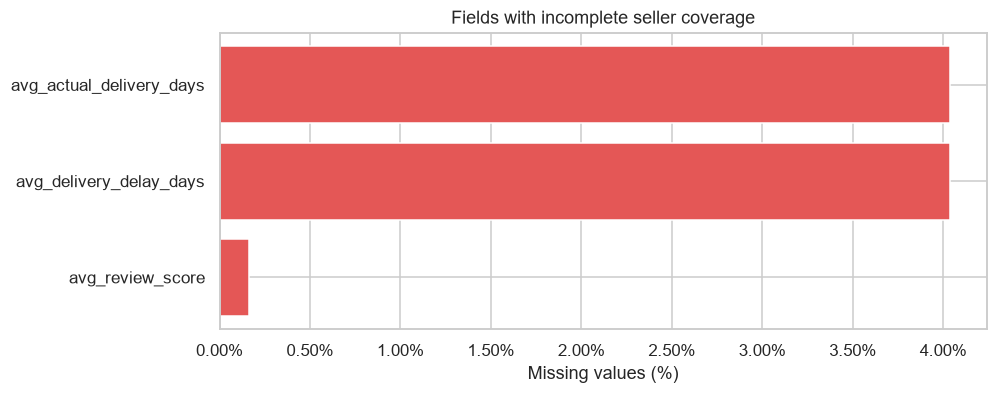

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
missing = audit.query('missing_rate > 0').sort_values('missing_rate')
ax.barh(missing.index, missing['missing_rate'] * 100, color='#e45756')
ax.set(title='Fields with incomplete seller coverage', xlabel='Missing values (%)', ylabel='')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
save_fig('seller_missing_values.png')
plt.show()


In [4]:
print('Sellers with at least one review:', sellers['has_reviews'].sum(),
      f"({sellers['has_reviews'].mean():.1%})")
print('Sellers with at least one delivered order:', sellers['has_delivered_orders'].sum(),
      f"({sellers['has_delivered_orders'].mean():.1%})")
print('active_seller_flag distinct values:', sellers['active_seller_flag'].unique())


Sellers with at least one review: 3090 (99.8%)
Sellers with at least one delivered order: 2970 (96.0%)
active_seller_flag distinct values: [ True]


**Data-quality caveat:** `active_seller_flag` is `True` for every single row in this table. It
currently carries no discriminating information — it cannot be used to separate active from
inactive sellers in this dataset. This should be revisited upstream (in
`data-processing-seller_master.ipynb`, where the flag is computed) before it's relied on for any
"active vs. inactive" filter or dashboard control. Every finding below therefore treats all 3,095
rows as the seller base under study, without an active/inactive split.

## 2. Seller base & revenue concentration

First the shape of the seller base (where sellers are, how many items they move), then how
concentrated revenue is across sellers — deciding whether growth here is a *long-tail* story or a
*few whales* story.

**Exploratory — seller volume by state**

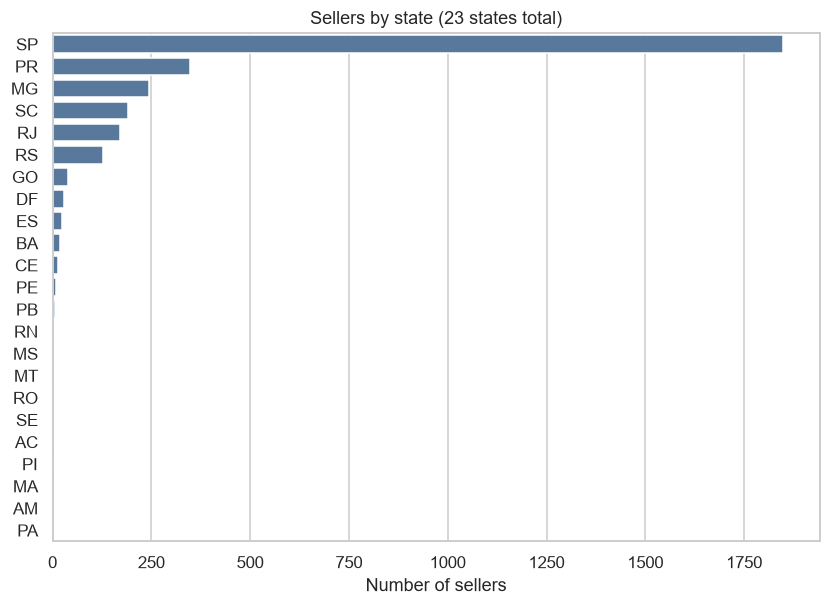

In [5]:
state_counts = sellers['seller_state'].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=state_counts.values, y=state_counts.index, color='#4c78a8', ax=ax)
ax.set(title=f'Sellers by state ({sellers["seller_state"].nunique()} states total)',
       xlabel='Number of sellers', ylabel='')
save_fig('seller_state_volume.png')
plt.show()


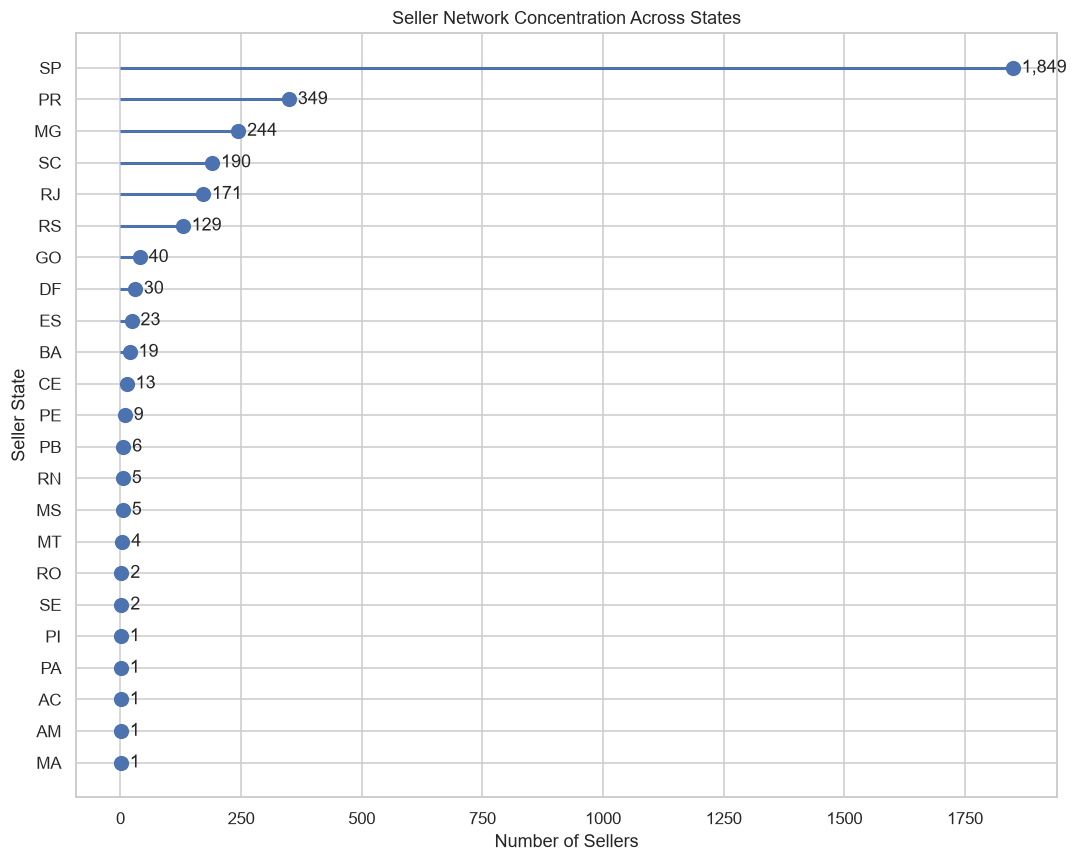

In [20]:


# Seller count by state
seller_count = (
    sellers["seller_state"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 8))

plt.hlines(
    y=range(len(seller_count)),
    xmin=0,
    xmax=seller_count.values,
    linewidth=2
)

plt.scatter(
    seller_count.values,
    range(len(seller_count)),
    s=80
)

plt.yticks(
    range(len(seller_count)),
    seller_count.index
)

plt.xlabel("Number of Sellers")
plt.ylabel("Seller State")
plt.title("Seller Network Concentration Across States")

# Add values
for i, value in enumerate(seller_count.values):
    plt.text(
        value + seller_count.max() * 0.01,
        i,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [18]:
state

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

**Focused — Lorenz / Pareto curve of seller revenue**

,top_pct,sellers,revenue_share
0,1,30,0.26
1,5,154,0.53
2,10,309,0.67
3,20,619,0.83
4,50,1547,0.97


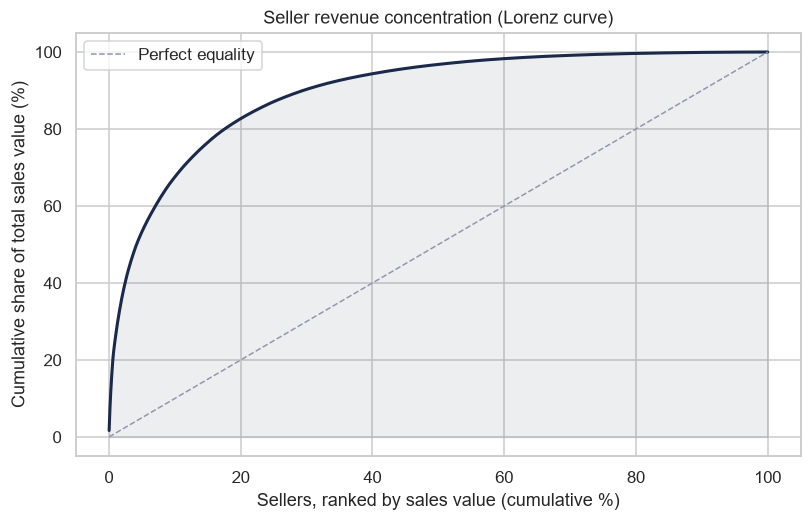

In [6]:
ranked = sellers.sort_values('total_item_sales_value', ascending=False).reset_index(drop=True)
ranked['cum_share'] = ranked['total_item_sales_value'].cumsum() / total_sales
conc = pd.DataFrame({'top_pct': [1, 5, 10, 20, 50]})
conc['sellers'] = (conc['top_pct'] / 100 * len(ranked)).astype(int).clip(lower=1)
conc['revenue_share'] = conc['sellers'].apply(lambda n: ranked['total_item_sales_value'].head(n).sum() / total_sales)
display(conc)

x = np.arange(1, len(ranked) + 1) / len(ranked) * 100
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(x, ranked['cum_share'] * 100, color=PALETTE['navy'], lw=2)
ax.fill_between(x, ranked['cum_share'] * 100, color=PALETTE['navy'], alpha=0.08)
ax.plot([0, 100], [0, 100], ls='--', color=PALETTE['grey'], lw=1, label='Perfect equality')
ax.set(title='Seller revenue concentration (Lorenz curve)',
       xlabel='Sellers, ranked by sales value (cumulative %)',
       ylabel='Cumulative share of total sales value (%)')
ax.legend()
save_fig('seller_revenue_concentration.png')
plt.show()


**Reading it together:** the seller base is heavily concentrated in **SP** (about 60% of all
sellers), and revenue is a long-tail story: the top 10% of sellers generate roughly two-thirds of
total item sales value, and the top 1% alone account for around a quarter. Losing a handful of
top sellers would matter far more to marketplace GMV than losing dozens of small ones — which
should weight how "seller risk" gets prioritized later in this notebook.

## 3. Review coverage & satisfaction

Average review score per seller, and how much of the seller base actually has a score to look at.

**Exploratory — distribution of average review score**

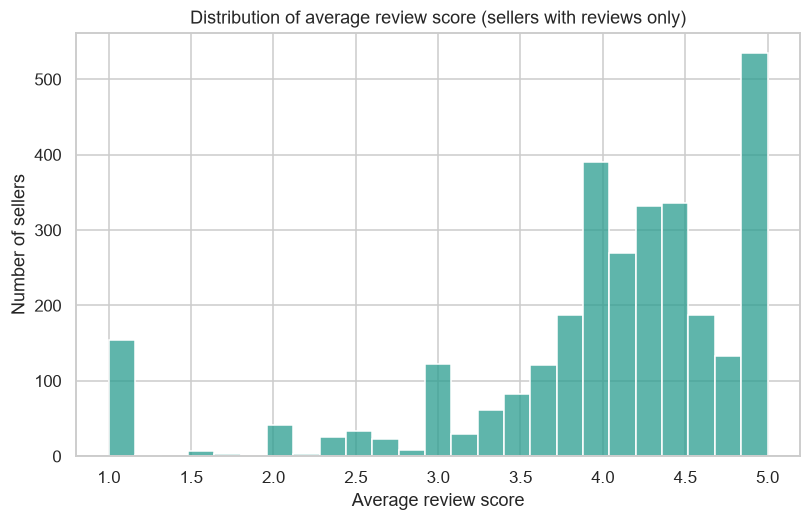

count   3,090.00
mean        4.00
std         0.96
min         1.00
25%         3.78
50%         4.18
75%         4.60
max         5.00
Name: avg_review_score, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.histplot(sellers.loc[sellers['has_reviews'], 'avg_review_score'], bins=25, color='#2a9d8f', ax=ax)
ax.set(title='Distribution of average review score (sellers with reviews only)',
       xlabel='Average review score', ylabel='Number of sellers')
save_fig('seller_review_score_dist.png')
plt.show()

print(sellers.loc[sellers['has_reviews'], 'avg_review_score'].describe())


**Focused — review coverage split** (a bar, not a pie: Cleveland & McGill's accuracy ranking
places position/length above angle for judging magnitude, so a two-category bar is read more
accurately than the equivalent pie slices)

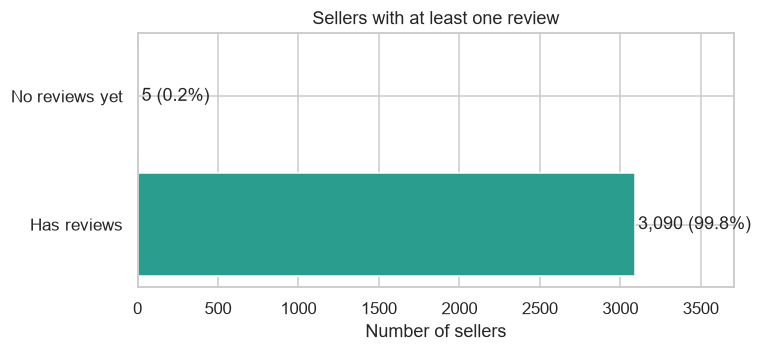

In [8]:
review_coverage = sellers['has_reviews'].value_counts().rename({True: 'Has reviews', False: 'No reviews yet'})

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(review_coverage.index, review_coverage.values,
                color=[PALETTE['green'], PALETTE['grey']])
for bar, count in zip(bars, review_coverage.values):
    pct = count / review_coverage.sum() * 100
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{count:,} ({pct:.1f}%)', va='center')
ax.set(title='Sellers with at least one review', xlabel='Number of sellers', ylabel='')
ax.set_xlim(0, review_coverage.max() * 1.2)
save_fig('seller_review_coverage.png')
plt.show()


99.8% of sellers (3,090 of 3,095) have at least one review, averaging close to **4.0 / 5**. Only
5 sellers have no review yet — too small a group to analyze separately, but the flag keeps them
from being silently excluded or treated as a 0 score in any aggregate.

## 4. Delivery performance & its link to reviews

The core operational driver: does a seller's delivery reliability show up in their review score?

**Exploratory — delivery delay distribution (days; negative = early)**

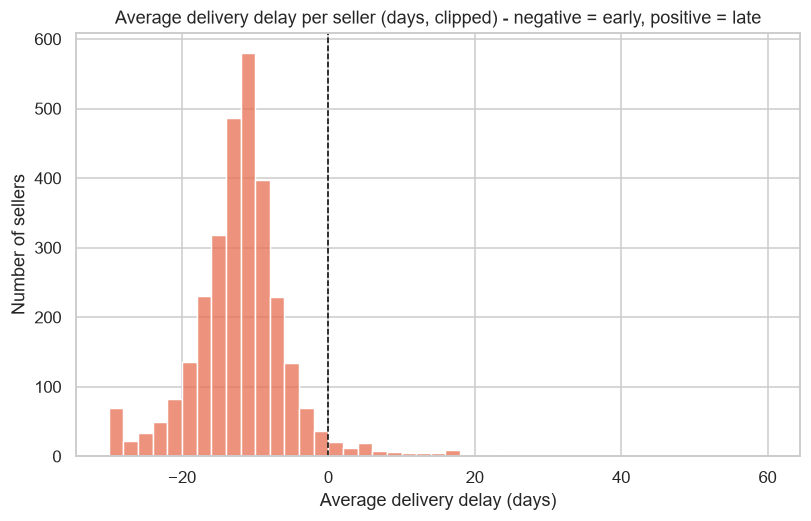

count   2,970.00
mean      -12.22
std         8.05
min       -66.00
25%       -15.33
50%       -11.88
75%        -9.00
max       167.00
Name: avg_delivery_delay_days, dtype: float64
Sellers delivering early on average: 2873 (96.7%)


In [9]:
delivered = sellers.loc[sellers['has_delivered_orders']].copy()

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.histplot(delivered['avg_delivery_delay_days'].clip(-30, 60), bins=45, color='#e76f51', ax=ax)
ax.axvline(0, color='black', ls='--', lw=1)
ax.set(title='Average delivery delay per seller (days, clipped) - negative = early, positive = late',
       xlabel='Average delivery delay (days)', ylabel='Number of sellers')
save_fig('seller_delivery_delay_dist.png')
plt.show()

print(delivered['avg_delivery_delay_days'].describe())
print('Sellers delivering early on average:', (delivered['avg_delivery_delay_days'] < 0).sum(),
      f"({(delivered['avg_delivery_delay_days'] < 0).mean():.1%})")


**Focused — review score by late-delivery-rate band**

,sellers,avg_review
late_band,,
0% late,1819,4.06
<=5% late,310,4.21
5-20% late,734,4.01
20%+ late,227,3.15


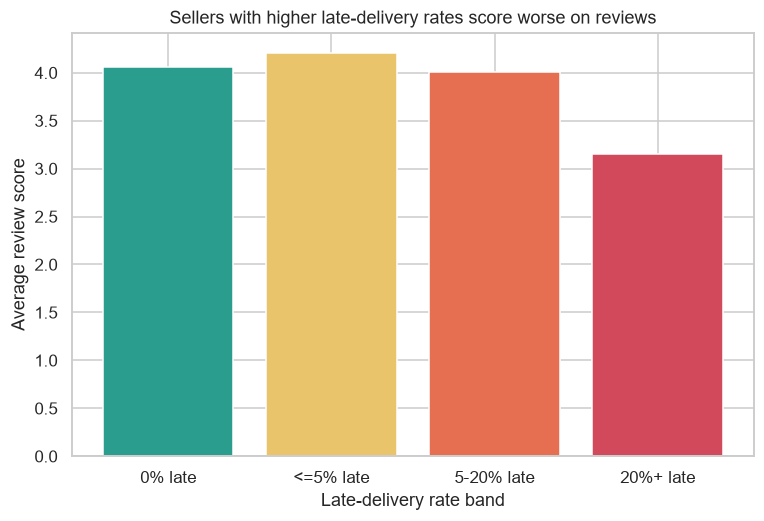

In [10]:
bands = pd.cut(sellers['late_delivery_rate'], [-0.01, 0, 0.05, 0.2, 1.01],
               labels=['0% late', '<=5% late', '5-20% late', '20%+ late'])
delivery_view = (sellers.loc[sellers['has_reviews']].assign(late_band=bands.loc[sellers['has_reviews']])
    .groupby('late_band', observed=True)
    .agg(sellers=('seller_id', 'count'), avg_review=('avg_review_score', 'mean'))
)
display(delivery_view)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE['green'], PALETTE['amber'], PALETTE['orange'], PALETTE['red']]
ax.bar(delivery_view.index.astype(str), delivery_view['avg_review'], color=colors, edgecolor='white')
ax.set(title='Sellers with higher late-delivery rates score worse on reviews',
       xlabel='Late-delivery rate band', ylabel='Average review score')
save_fig('seller_review_by_late_band.png')
plt.show()


**Correlation check (sellers with both a review and at least one delivered order)**

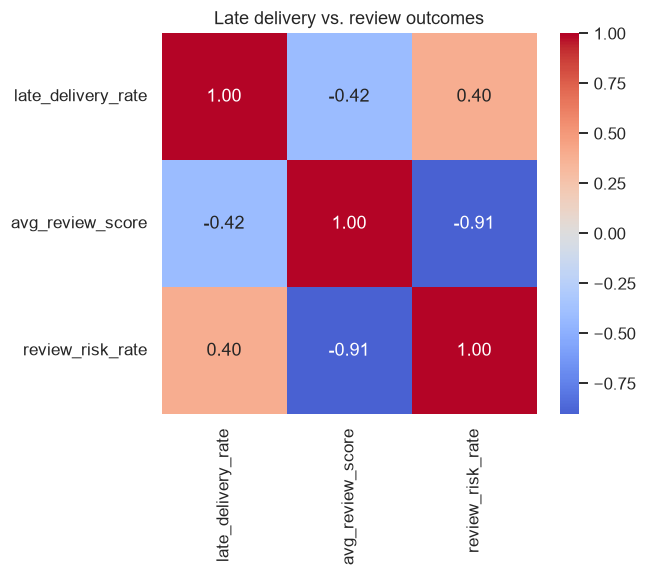

In [11]:
corr_cols = ['late_delivery_rate', 'avg_review_score', 'review_risk_rate']
eligible = sellers.loc[sellers['has_reviews'] & sellers['has_delivered_orders']]
correlation = eligible[corr_cols].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Late delivery vs. review outcomes')
save_fig('seller_delivery_review_correlation.png')
plt.show()


**Reading it together:** most sellers beat their own delivery estimate (97% have a negative
average delay), and the marketplace over-delivers on its promises as a whole. But the late-delivery
**rate** distribution has a real tail: about 1 in 13 sellers has a late-delivery rate above 20%, and
that tail scores meaningfully worse on reviews. Late-delivery rate and average review score are
negatively correlated (~-0.42), echoing the same pattern found at the order and customer level -
but this is an association across sellers, not proof that lateness itself causes the lower score.
A seller with weak operations (understaffed, poor packaging, unreliable suppliers) could plausibly
produce both late shipments and low reviews as separate symptoms of the same underlying problem,
so the correlation alone doesn't rule out a shared-cause explanation. The order-level notebook
(`eda_master_orders_table.ipynb`) shows the same delay-band drop in review score *within* orders
over time, which is harder to explain by a fixed seller trait alone and makes a genuine delivery
effect more plausible - but a same-seller, late-vs-on-time comparison would be the stronger test.

## 5. Priority segments: high-value sellers with review risk

The company can't treat every risky seller the same way - a large, high-revenue seller with quality
problems is a bigger threat to customer experience than a small one. This section combines revenue
contribution with `review_risk_flag` to find where intervention matters most.

**Exploratory — how many sellers are flagged as review-risk?**

In [12]:
risk_counts = sellers['review_risk_flag'].value_counts()
print(risk_counts)
print(f"Review-risk rate across all sellers: {sellers['review_risk_flag'].mean():.1%}")


review_risk_flag
False    2887
True      208
Name: count, dtype: int64
Review-risk rate across all sellers: 6.7%


**Focused — value x risk quadrant**

,sellers,total_sales,avg_review,avg_late_rate
priority_segment,,,,
High-value and healthy,769,"11,788,006.15",4.09,0.07
Lower-value and healthy,2118,"1,690,679.90",4.23,0.05
Lower-value and at-risk,203,"62,377.60",1.22,0.15
High-value and at-risk,5,"50,580.05",1.44,0.37


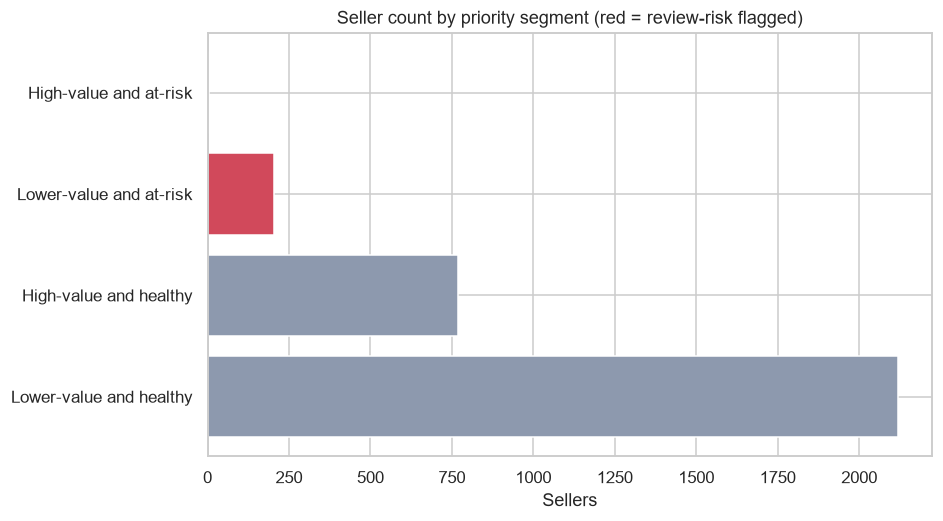

In [13]:
value_cut = sellers['total_item_sales_value'].quantile(0.75)
sellers['value_tier'] = np.where(sellers['total_item_sales_value'] >= value_cut, 'High-value', 'Lower-value')
sellers['priority_segment'] = np.select(
    [
        (sellers['value_tier'] == 'High-value') & sellers['review_risk_flag'],
        (sellers['value_tier'] == 'High-value') & ~sellers['review_risk_flag'],
        (sellers['value_tier'] == 'Lower-value') & sellers['review_risk_flag'],
    ],
    ['High-value and at-risk', 'High-value and healthy', 'Lower-value and at-risk'],
    default='Lower-value and healthy'
)

segment_summary = (sellers.groupby('priority_segment')
    .agg(sellers=('seller_id', 'count'),
         total_sales=('total_item_sales_value', 'sum'),
         avg_review=('avg_review_score', 'mean'),
         avg_late_rate=('late_delivery_rate', 'mean'))
    .sort_values('total_sales', ascending=False))
display(segment_summary)

fig, ax = plt.subplots(figsize=(8.5, 5))
order = segment_summary.sort_values('sellers', ascending=False).index
colors = [PALETTE['red'] if 'at-risk' in s else PALETTE['grey'] for s in order]
ax.barh(order, segment_summary.loc[order, 'sellers'], color=colors)
ax.set(title='Seller count by priority segment (red = review-risk flagged)', xlabel='Sellers', ylabel='')
save_fig('seller_priority_segments.png')
plt.show()


**Reading the quadrant:** review risk is heavily concentrated among **lower-value** sellers - 203
of the 208 review-risk-flagged sellers are in the bottom three revenue quartiles, versus only 5
among the top-quartile "High-value" group (769 of 774 top-quartile sellers are review-risk healthy).
In other words, the marketplace's biggest revenue drivers are, on the whole, already reliable; review
risk is disproportionately a small-seller problem. That reframes the priority list: the tiny
"High-value and at-risk" group (5 sellers) deserves white-glove account management given their
revenue weight, but the **volume** of the risk problem sits in "Lower-value and at-risk" (203
sellers) - a segment better addressed with scalable interventions (automated coaching, onboarding
changes, policy nudges) than one-on-one outreach, since neither has enough sellers to fix on its own
the shape of the wider quality picture.

## 6. Category diversity, tenure, and volume - do they predict quality?

Three plausible "does this predict better performance" questions, checked directly against the
data rather than assumed.

**Exploratory — category diversity vs. sales value**

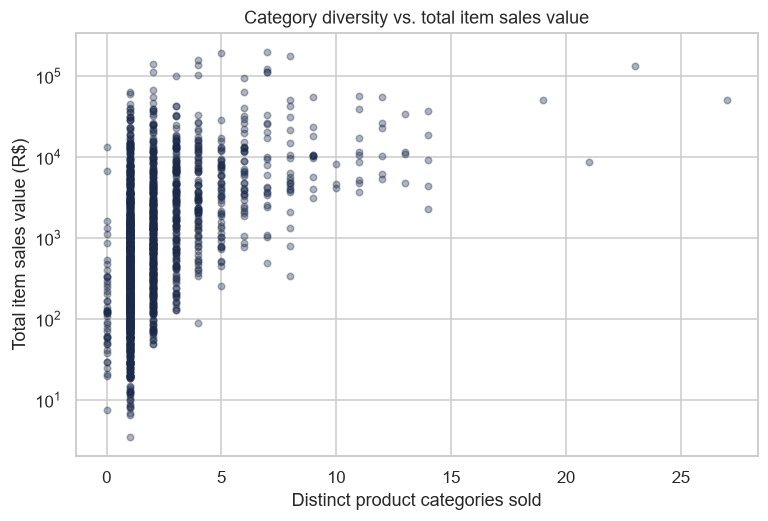

Correlation (category_diversity, total_item_sales_value): 0.32


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sample = sellers.sample(min(2000, len(sellers)), random_state=1)
ax.scatter(sample['category_diversity'], sample['total_item_sales_value'], alpha=0.35, s=18, color=PALETTE['navy'])
ax.set(title='Category diversity vs. total item sales value', xlabel='Distinct product categories sold',
       ylabel='Total item sales value (R$)', yscale='log')
save_fig('seller_category_diversity_vs_sales.png')
plt.show()

print('Correlation (category_diversity, total_item_sales_value):',
      round(sellers['category_diversity'].corr(sellers['total_item_sales_value']), 2))


**Focused — tenure and volume vs. review score / late-delivery rate**

,seller_tenure_days,avg_review_score,late_delivery_rate
seller_tenure_days,1.00,0.08,0.01
avg_review_score,0.08,1.00,-0.30
late_delivery_rate,0.01,-0.30,1.00


,sellers,avg_review,avg_late_rate
volume_tier,,,
High-volume,1456,4.11,0.06
Low-volume,1639,3.90,0.06


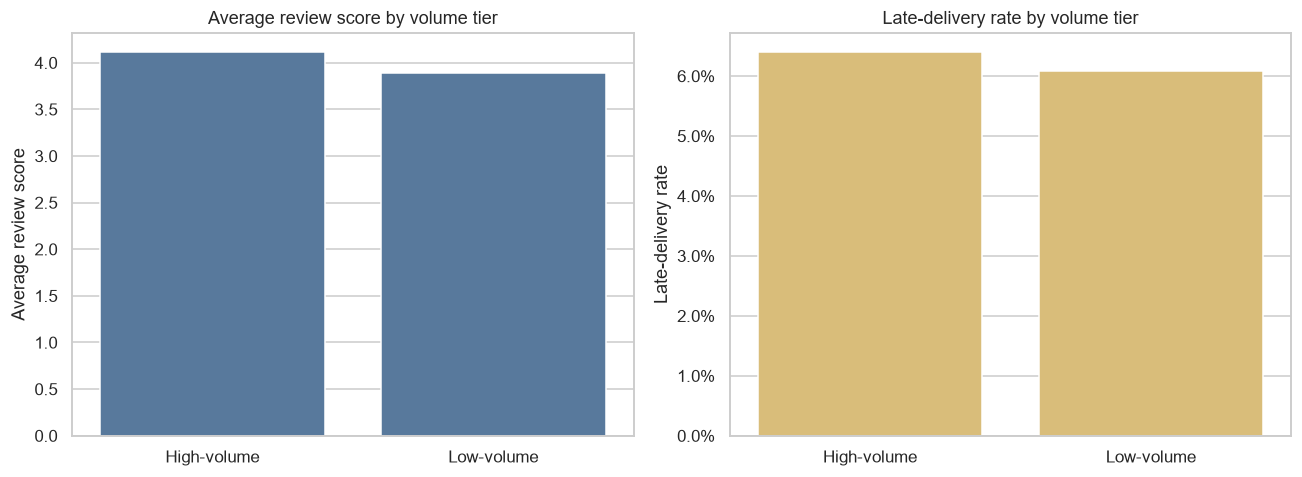

In [15]:
tenure_corr = sellers[['seller_tenure_days', 'avg_review_score', 'late_delivery_rate']].corr()
display(tenure_corr)

median_items = sellers['total_items_sold'].median()
sellers['volume_tier'] = np.where(sellers['total_items_sold'] > median_items, 'High-volume', 'Low-volume')
volume_view = (sellers.groupby('volume_tier')
    .agg(sellers=('seller_id', 'count'),
         avg_review=('avg_review_score', 'mean'),
         avg_late_rate=('late_delivery_rate', 'mean'))
)
display(volume_view)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=volume_view.reset_index(), x='volume_tier', y='avg_review', color='#4c78a8', ax=axes[0])
axes[0].set(title='Average review score by volume tier', xlabel='', ylabel='Average review score')
sns.barplot(data=volume_view.reset_index(), x='volume_tier', y='avg_late_rate', color='#e9c46a', ax=axes[1])
axes[1].set(title='Late-delivery rate by volume tier', xlabel='', ylabel='Late-delivery rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
save_fig('seller_volume_tier_comparison.png')
plt.show()


**Findings:**
- Category diversity has only a weak positive correlation with sales value (~+0.32) - a plausible
  but secondary growth lever, not a strong driver.
- Seller tenure has essentially no relationship with review score (~+0.08) or late-delivery rate
  (~+0.01) - being on the platform longer does not, by itself, make a seller more reliable.
- High-volume sellers (above-median items sold) actually have a **higher** average review score
  than low-volume sellers, despite a marginally higher late-delivery rate - this pushes back on the
  assumption that scaling seller volume inherently degrades quality; experienced/high-volume
  sellers appear to run more efficient operations overall.

## 7. Geographic freight cost

Freight cost relative to sales value, by state - useful context so a seller in a distant state
isn't judged unfairly on cost efficiency against one in the logistics core.

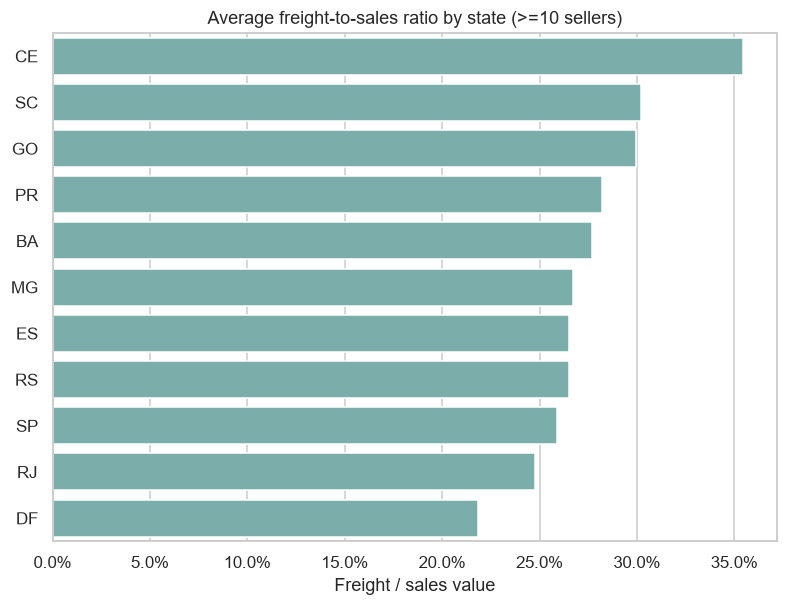

,sellers,avg_freight_ratio
seller_state,,
CE,13,0.35
SC,190,0.30
GO,40,0.30
PR,349,0.28
BA,19,0.28


In [16]:
sellers['freight_ratio'] = sellers['total_item_freight_value'] / sellers['total_item_sales_value']

state_freight = (sellers.groupby('seller_state')
    .agg(sellers=('seller_id', 'count'), avg_freight_ratio=('freight_ratio', 'mean'))
    .query('sellers >= 10')
    .sort_values('avg_freight_ratio', ascending=False)
)

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.barplot(data=state_freight.reset_index(), y='seller_state', x='avg_freight_ratio', color='#72b7b2', ax=ax)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set(title='Average freight-to-sales ratio by state (>=10 sellers)', xlabel='Freight / sales value', ylabel='')
save_fig('seller_freight_by_state.png')
plt.show()

state_freight.head(5)


States furthest from the Southeast logistics core (e.g. **PE, CE, PB, MA, MT**) carry a
noticeably higher freight-to-sales ratio than SP/PR/MG - a structural, geography-driven cost rather
than a sign of seller inefficiency. Worth surfacing as context in the dashboard whenever seller
cost metrics are compared across regions.

## 8. Takeaways, actions & open questions

**Auto-generated headline numbers (from the cells above)**

In [17]:
top10_revenue_share = conc.loc[conc['top_pct'] == 10, 'revenue_share'].iloc[0]
at_risk_high_value = int(segment_summary.loc['High-value and at-risk', 'sellers']) if 'High-value and at-risk' in segment_summary.index else 0
late_tail_share = (sellers['late_delivery_rate'] > 0.2).mean()
review_risk_rate_overall = sellers['review_risk_flag'].mean()

print(f'Sellers analyzed: {len(sellers):,}')
print(f'Top 10% of sellers share of total sales: {top10_revenue_share:.1%}')
print(f'High-value AND review-risk sellers: {at_risk_high_value}')
print(f'Sellers with a late-delivery rate above 20%: {late_tail_share:.1%}')
print(f'Overall review-risk rate: {review_risk_rate_overall:.1%}')


Sellers analyzed: 3,095
Top 10% of sellers share of total sales: 67.5%
High-value AND review-risk sellers: 5
Sellers with a late-delivery rate above 20%: 7.4%
Overall review-risk rate: 6.7%


**Findings**

1. **Long-tail revenue, whale-sensitive risk.** The top 10% of sellers generate roughly two-thirds
   of total sales value, and the top 1% alone about a quarter - losing a handful of top sellers
   would hurt GMV far more than losing many small ones.
2. **Delivery reliability and satisfaction move together at the seller level too.** Late-delivery
   rate and average review score are negatively correlated (~-0.42); a real tail of sellers (~7-8%)
   has a late-delivery rate above 20% and measurably worse reviews - a clear, boundable
   intervention target. This is correlational: a seller with broader operational problems could
   plausibly produce both symptoms independently, so treat it as a strong candidate lever, not a
   proven causal one, pending a same-seller late-vs-on-time comparison (see Section 4).
3. **Review risk is concentrated among lower-value sellers, not top sellers.** Only 5 of 774
   top-revenue-quartile sellers are review-risk flagged, versus 203 of 2,321 lower-value sellers.
   The few high-value, at-risk sellers warrant individual account management given their revenue
   weight; the larger lower-value, at-risk group needs a scalable intervention (coaching,
   onboarding changes) rather than one-on-one outreach.
4. **Volume and tenure don't predict quality the way intuition might suggest.** Tenure has no
   measurable relationship with review score or late-delivery rate; high-volume sellers actually
   score *better* on reviews than low-volume ones. Scaling seller volume is not, by itself, a
   quality risk.
5. **Geography drives freight cost, not seller behaviour.** Sellers in outlying states carry a
   structurally higher freight-to-sales ratio - a logistics-network fact (distance mechanically
   raises shipping cost), not a spurious association with seller behaviour.

**Data caveat to carry forward:** `active_seller_flag` is `True` for 100% of rows in this table and
should not be used for any active/inactive comparison until fixed upstream in
`data-processing-seller_master.ipynb`.

**Open questions for the combined analysis**
- Do sellers sourced through better-converting marketing channels (see the marketing funnel
  analysis) turn into better-performing sellers here? The two tables share no direct key today
  (`seller_id` in this table vs. the funnel's `seller_id` on converted leads) - joining them is the
  natural next step connecting acquisition quality to seller-side outcomes.
- Would coaching or temporarily de-prioritizing the ~230-seller late-delivery tail measurably move
  the marketplace-wide review average, or is the effect too diluted by the other 97% of the base?


## Reporting guidance & limitations

Tell a supply-side growth story: revenue is concentrated in a small set of sellers, delivery
reliability (not tenure or volume) is the clearest correlate of satisfaction, and a small
"high-value, at-risk" segment is the highest-leverage place to intervene without shrinking the
catalogue.

*Limitations:* this is completed historical behaviour aggregated over each seller's full history,
not a live operational snapshot - a seller who improved recently and one who is currently declining
can show the same lifetime average. The delivery-reliability/review-score relationship is
correlational (see Section 4) - it supports monitoring and intervention, not a proven causal claim.
`active_seller_flag` cannot support an active/inactive read in its current state (see Section 1).
`avg_review_score` and delivery-delay metrics are undefined for 5 and 125 sellers respectively
(`has_reviews` / `has_delivered_orders` flags mark these) and are excluded, not imputed, in every
relevant chart above.